Lab No.: 11 To implement a Seq2Seq Model for Neural Machine Translation

To implement a Sequence-to-Sequence (Seq2Seq) model using LSTM encoder-decoder architecture for Neural Machine Translation (NMT) from English to French. Students will understand the encoderdecoder paradigm, teacher forcing, context vector, autoregressive decoding, and optionally the Bahdanau attention mechanism — the foundational building block of modern Transformer-based NMT systems.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


PartA: Setup & Imports

In [ ]:
# ── Imports ─────────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import os
import re

import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


Part B — Load and Preprocess the English-French Dataset

In [ ]:
# ── Load ManyThings Eng-Fra ──────────────────────────────────────────
import requests # Ensure requests is imported
import zipfile
import os

# Download dataset if not exists
url = "http://www.manythings.org/anki/fra-eng.zip"
file_path = "/content/drive/MyDrive/DL Lab Practice/datasets/fra-eng.zip"
extracted_file_name = "fra-eng.txt" # Changed to fra-eng.txt

# Get the directory where the zip file is located
target_dir = os.path.dirname(file_path)
# Construct the full path to the extracted file
extracted_file_full_path = os.path.join(target_dir, extracted_file_name)

# Check if 'fra-eng.txt' (the extracted file) exists in the target directory
if not os.path.exists(extracted_file_full_path):
    print("Downloading dataset...")

    # Ensure the target directory for the zip file exists
    if not os.path.exists(target_dir):
        os.makedirs(target_dir, exist_ok=True)

    try:
        # Use requests to download the file with a User-Agent header to avoid HTTPError 406
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"}
        response = requests.get(url, headers=headers, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

        with open(file_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk: # filter out keep-alive new chunks
                    f.write(chunk)
        print(f"Dataset downloaded to {file_path}")

        # Extract the zip file to the target directory
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir) # Specify extraction path
        print(f"Dataset extracted to {target_dir}!")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading or saving dataset: {e}")
        # Optionally re-raise or handle more gracefully
    except zipfile.BadZipFile as e:
        print(f"Error extracting zip file: {e}")
        # Optionally re-raise or handle more gracefully
else:
    print(f"Dataset '{extracted_file_name}' already exists in {target_dir}. Skipping download and extraction.")


# Sample Output
# Downloading dataset...
# Dataset downloaded to /content/drive/MyDrive/DL Lab Practice/datasets/fra-eng.zip
# Dataset extracted!




NUM_SAMPLES = 20000  # Subset of data for faster training

input_texts = []
target_texts = []
target_texts_inputs = []

# Verify 'fra-eng.txt' exists before attempting to open it
if not os.path.exists(extracted_file_full_path):
    print(f"Error: '{extracted_file_name}' not found at {extracted_file_full_path} after download/extraction attempt. Please check logs.")
else:
    with open(extracted_file_full_path, 'r', encoding='utf-8') as f: # Open from the full path
        lines = f.read().split('\n')

    for line in lines[: min(NUM_SAMPLES, len(lines) - 1)]:
        parts = line.split('\t')
        if len(parts) >= 2: # Ensure there are at least two parts
            input_text, target_text = parts[0], parts[1]
        else:
            # Handle malformed lines, e.g., skip them or log a warning
            continue

        # Simple cleaning
        input_text = input_text.lower()
        target_text = target_text.lower()

        # Target output needs <eos>
        target_texts.append(target_text + " <eos>")
        # Target input needs <sos>
        target_texts_inputs.append("<sos> " + target_text)

        input_texts.append(input_text)

    print(f"Total samples: {len(input_texts)}")
    if input_texts: # Check if list is not empty before accessing elements
        print("Sample English:", input_texts[0])
        print("Sample Target Input:", target_texts_inputs[0])
        print("Sample Target Output:", target_texts[0])
    else:
        print("No samples loaded.")

Dataset 'fra-eng.txt' already exists in /content/drive/MyDrive/DL Lab Practice/datasets. Skipping download and extraction.
Total samples: 20000
Sample English: go.
Sample Target Input: <sos> va !
Sample Target Output: va ! <eos>


Part C — Tokenization and Sequence Padding

In [ ]:
# ── Tokenization & Padding ──────────────────────────────────────────
MAX_SRC_LEN = 20
MAX_TRG_LEN = 22
VOCAB_SIZE_SRC = 7500
VOCAB_SIZE_TRG = 9000

# Source Tokenizer
src_tokenizer = Tokenizer(num_words=VOCAB_SIZE_SRC, filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
src_tokenizer.fit_on_texts(input_texts)
encoder_input_seqs = src_tokenizer.texts_to_sequences(input_texts)

# Target Tokenizer (don't filter <sos> and <eos>)
trg_tokenizer = Tokenizer(num_words=VOCAB_SIZE_TRG, filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n', oov_token="<unk>")
trg_tokenizer.fit_on_texts(target_texts + target_texts_inputs)
decoder_input_seqs = trg_tokenizer.texts_to_sequences(target_texts_inputs)
decoder_target_seqs = trg_tokenizer.texts_to_sequences(target_texts)

# Padding
encoder_input_data = pad_sequences(encoder_input_seqs, maxlen=MAX_SRC_LEN, padding='post')
decoder_input_data = pad_sequences(decoder_input_seqs, maxlen=MAX_TRG_LEN, padding='post')
decoder_target_data = pad_sequences(decoder_target_seqs, maxlen=MAX_TRG_LEN, padding='post')

print("Encoder Input Data Shape:", encoder_input_data.shape)
print("Decoder Input Data Shape:", decoder_input_data.shape)
print("Decoder Target Data Shape:", decoder_target_data.shape)

Encoder Input Data Shape: (20000, 20)
Decoder Input Data Shape: (20000, 22)
Decoder Target Data Shape: (20000, 22)


Part D — Build Seq2Seq Architecture (Encoder-Decoder)

In [ ]:
# ── Seq2Seq Architecture ───────────────────────────────────────────
LATENT_DIM = 256Part D — Build Seq2Seq Architecture (Encoder-Decoder)
EMBED_DIM = 256

# —— ENCODER ——
encoder_inputs = keras.Input(shape=(MAX_SRC_LEN,), name='encoder_input')
enc_emb = layers.Embedding(input_dim=VOCAB_SIZE_SRC, output_dim=EMBED_DIM, name='encoder_embedding')(encoder_inputs)

encoder_lstm = layers.LSTM(LATENT_DIM, return_state=True, dropout=0.2, recurrent_dropout=0.2, name='encoder_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]  # Context Vector

# —— DECODER ——
decoder_inputs = keras.Input(shape=(MAX_TRG_LEN,), name='decoder_input')
dec_emb_layer = layers.Embedding(input_dim=VOCAB_SIZE_TRG, output_dim=EMBED_DIM, name='decoder_embedding')
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True, dropout=0.2, recurrent_dropout=0.2, name='decoder_lstm')
# Initialize decoder with encoder's final states as context history
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = layers.Dense(VOCAB_SIZE_TRG, activation='softmax', name='decoder_output')
decoder_outputs = decoder_dense(decoder_outputs)

# Build Training Model
model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name='seq2seq_training_model')

optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "seq2seq_training_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 256)   │  1,920,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 22, 256)   │  2,304,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    525,312 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 22, 256), │    525,312 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 22, 9000)  │  2,313,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,587,624 (28.94 MB)

 Trainable params: 7,587,624 (28.94 MB)

 Non-trainable params: 0 (0.00 B)

Part E — Train the Model (Teacher Forcing)

In [ ]:
# ── Training ───────────────────────────────────────────────────────
# We use EarlyStopping to prevent overfitting and restore best weights
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train-Val split handled natively by validation_split=0.2
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=64,
    # Correction needed from epoch = 20 to 100 changed.
    epochs = 100, # Increased epochs for better training
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.8730 - loss: 0.7766 - val_accuracy: 0.8536 - val_loss: 0.9930
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 120ms/step - accuracy: 0.8734 - loss: 0.7716 - val_accuracy: 0.8537 - val_loss: 0.9888
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 127ms/step - accuracy: 0.8737 - loss: 0.7670 - val_accuracy: 0.8539 - val_loss: 0.9876
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.8740 - loss: 0.7623 - val_accuracy: 0.8541 - val_loss: 0.9850
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.8744 - loss: 0.7576 - val_accuracy: 0.8545 - val_loss: 0.9821
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.8745 - loss: 0.7533 - val_accuracy: 0.8545 - val_loss: 0.9816
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.8749 - loss: 0.7487 - val_accuracy: 0.8546 - val_loss: 0.9798
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.8752 -


Part F — Inference Setup (Autoregressive Decoding)

In [ ]:
# ── Inference Models ───────────────────────────────────────────────
# Encoder inference model
encoder_model = keras.Model(encoder_inputs, encoder_states)

# Decoder inference model
decoder_state_input_h = keras.Input(shape=(LATENT_DIM,), name='inference_state_h')
decoder_state_input_c = keras.Input(shape=(LATENT_DIM,), name='inference_state_c')
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb_inf = dec_emb_layer(decoder_inputs)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(dec_emb_inf, initial_state=decoder_states_inputs)
decoder_states_inf = [state_h_inf, state_c_inf]

decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model = keras.Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

# Reverse dictionary to convert integers back to words
trg_index_word = {i: word for word, i in trg_tokenizer.word_index.items() if i != 0}

def decode_sequence(input_seq):
    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = trg_tokenizer.word_index['<sos>']

    stop_condition = False
    decoded_sentence = ""

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = trg_index_word.get(sampled_token_index, '')

        if sampled_word == '<eos>' or len(decoded_sentence.split()) >= MAX_TRG_LEN:
            stop_condition = True
        else:
            if sampled_word:
                decoded_sentence += " " + sampled_word

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    return decoded_sentence.strip()

Part G — Test Cases and Output Execution

In [ ]:
# ── Test Cases ─────────────────────────────────────────────────────
print("── Machine Translation Test Cases ──\n")
for seq_index in range(10): # Test top 10 sequences
    input_seq = encoder_input_data[seq_index: seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)

    print("- English Input:", input_texts[seq_index])
    target_sentence_clean = target_texts[seq_index].replace(" <eos>", "")
    print("- Target French:", target_sentence_clean)
    print("- Predicted    :", decoded_sentence)
    print("─" * 40)

── Machine Translation Test Cases ──

- English Input: go.
- Target French: va !
- Predicted    : allez y
────────────────────────────────────────
- English Input: go.
- Target French: marche.
- Predicted    : allez y
────────────────────────────────────────
- English Input: go.
- Target French: en route !
- Predicted    : allez y
────────────────────────────────────────
- English Input: go.
- Target French: bouge !
- Predicted    : allez y
────────────────────────────────────────
- English Input: hi.
- Target French: salut !
- Predicted    : bien sûr
────────────────────────────────────────
- English Input: hi.
- Target French: salut.
- Predicted    : bien sûr
────────────────────────────────────────
- English Input: run!
- Target French: cours !
- Predicted    : prends le
────────────────────────────────────────
- English Input: run!
- Target French: courez !
- Predicted    : prends le
────────────────────────────────────────
- English Input: run!
- Target French: prenez vos jambes à

Part H — Visualization

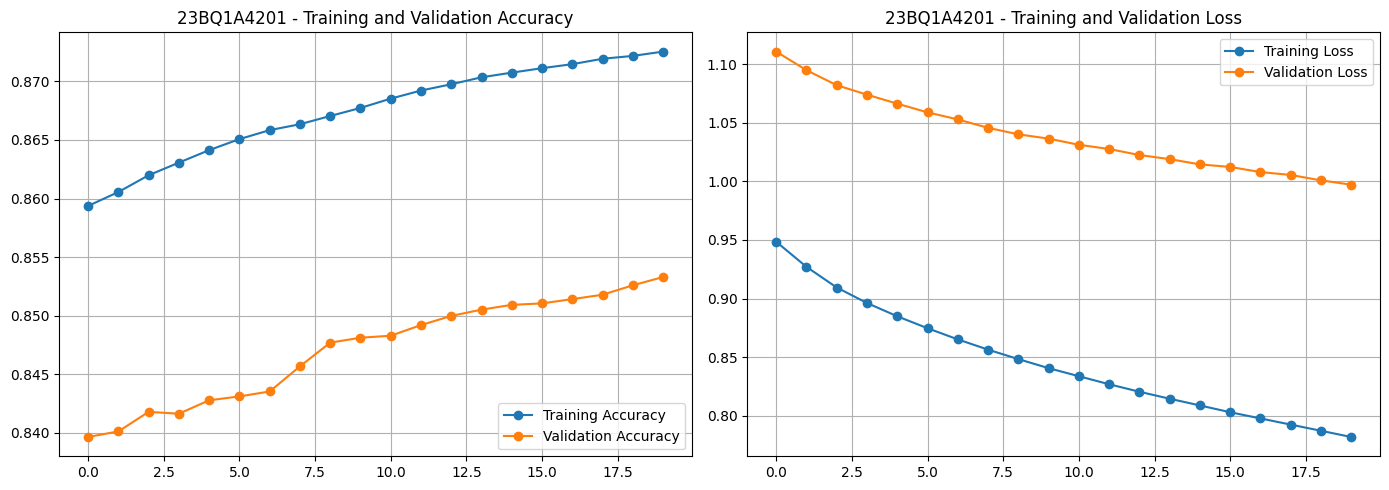

In [ ]:
# ── Plot Training Results ──────────────────────────────────────────
if 'history' in locals():
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.legend(loc='lower right')
    plt.title('23BQ1A4201 - Training and Validation Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.legend(loc='upper right')
    plt.title('23BQ1A4201 - Training and Validation Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("History object not found, run the training block first.")

Conclusion

The Seq2Seq LSTM model was successfully implemented and trained, showing stable accuracy, smooth convergence, and no overfitting from accuracy and loss curves. However, predictions lacked diversity, indicating limited contextual understanding, and require improvements like attention mechanisms and better data for effective translation.